<a href="https://colab.research.google.com/github/abiduldul/Numerical-Method/blob/main/Materi%202/Jacobi_Iteration_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sistem persamaan:\
x + 8y − 2z = −9\
−2x + 4y − 9z = −50\
10x − 3y + 6z = 24,5\

lessgoo dikerjakan menggunakan iterasi Jacobi

Matriks A (setelah reordering):
[[10. -3.  6.]
 [ 1.  8. -2.]
 [-2.  4. -9.]]

Vektor b: [ 24.5  -9.  -50. ]

CEK DIAGONAL DOMINAN:
  Baris 1: |10.0| = 10.0 > 9.0 (sum off-diag)  →  ✅ DOMINAN
  Baris 2: |8.0| = 8.0 > 3.0 (sum off-diag)  →  ✅ DOMINAN
  Baris 3: |-9.0| = 9.0 > 6.0 (sum off-diag)  →  ✅ DOMINAN

Solusi Eksak (numpy.linalg): x=-1.0000, y=0.5000, z=6.0000
  ITERASI JACOBI 
  Tebakan awal : x=0.0, y=0.0, z=0.0
  Toleransi    : 1e-06
------------------------------------------------------------------------
  Iter             x             y             z    Error max|Δ|
------------------------------------------------------------------------
     0      0.000000      0.000000      0.000000               —
     1      2.450000     -1.125000      5.555556    5.555556e+00
     2     -1.220833     -0.042361      4.511111    3.670833e+00
     3     -0.269375      0.155382      5.808025    1.296914e+00
     4     -0.988200      0.360678      5.684475    7.188252e-01
     5     -0.852

/tmp/ipykernel_3532/1606906325.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


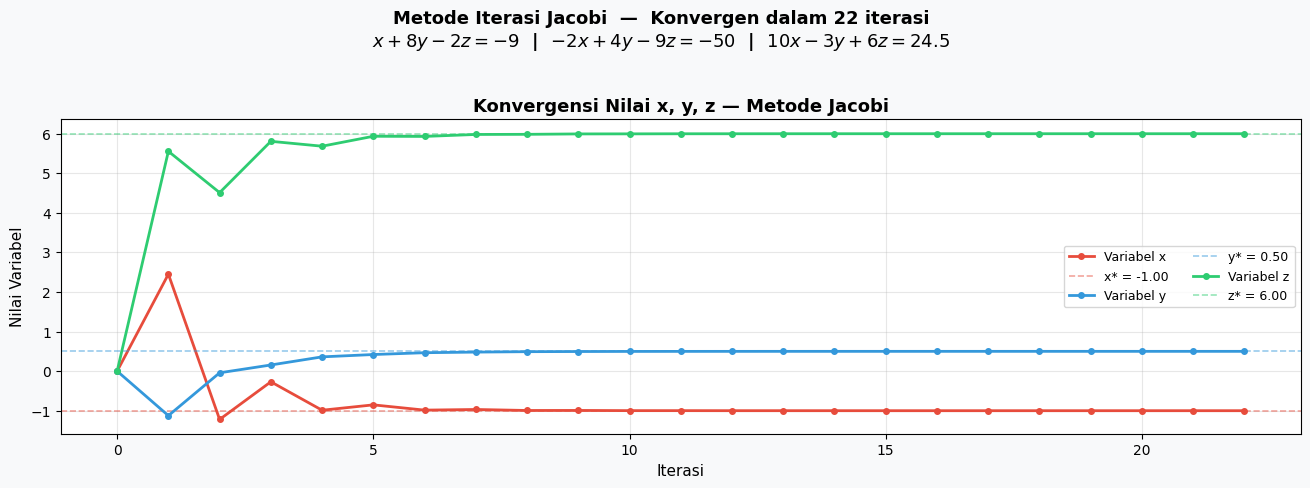

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display
import pandas as pd

# Matriks A (setelah reordering → diagonal dominan)
A = np.array([
    [10., -3.,  6.],   # 10x - 3y + 6z = 24.5
    [ 1.,  8., -2.],   #  x  + 8y - 2z = -9
    [-2.,  4., -9.]    # -2x + 4y - 9z = -50
], dtype=float)

b = np.array([24.5, -9.0, -50.0], dtype=float)

# Cek diagonal dominan
print("Matriks A (setelah reordering):")
print(A)
print(f"\nVektor b: {b}")
print("\n" + "="*50)
print("CEK DIAGONAL DOMINAN:")
print("="*50)
for i in range(3):
    diag  = abs(A[i, i])
    offdiag = sum(abs(A[i, j]) for j in range(3) if j != i)
    status  = "✅ DOMINAN" if diag > offdiag else "❌ TIDAK DOMINAN"
    print(f"  Baris {i+1}: |{A[i,i]}| = {diag} > {offdiag} (sum off-diag)  →  {status}")

# Solusi eksak sebagai referensi
x_exact = np.linalg.solve(A, b)
print(f"\nSolusi Eksak (numpy.linalg): x={x_exact[0]:.4f}, y={x_exact[1]:.4f}, z={x_exact[2]:.4f}")

def jacobi_method(A, b, tol=1e-6, max_iter=100):
    n = len(b)
    x = np.zeros(n)        # tebakan awal [0, 0, 0]
    history = [x.copy()]
    errors  = []

    print("=" * 72)
    print("  ITERASI JACOBI ")
    print("=" * 72)
    print(f"  Tebakan awal : x={x[0]}, y={x[1]}, z={x[2]}")
    print(f"  Toleransi    : {tol}")
    print("-" * 72)
    print(f"  {'Iter':>4}  {'x':>12}  {'y':>12}  {'z':>12}  {'Error max|Δ|':>14}")
    print("-" * 72)
    print(f"  {'0':>4}  {x[0]:>12.6f}  {x[1]:>12.6f}  {x[2]:>12.6f}  {'—':>14}")

    for k in range(1, max_iter + 1):
        x_new = np.zeros(n)

        # ── UPDATE SERENTAK: gunakan x^(k) lama untuk semua ──
        for i in range(n):
            sigma    = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - sigma) / A[i][i]

        error = np.max(np.abs(x_new - x))
        errors.append(error)
        history.append(x_new.copy())

        print(f"  {k:>4}  {x_new[0]:>12.6f}  {x_new[1]:>12.6f}  {x_new[2]:>12.6f}  {error:>14.6e}")

        x = x_new.copy()
        if error < tol:
            break

    print("-" * 72)
    return x, history, errors, k

# Jalankan Jacobi
tol = 1e-6
x_sol, history, errors, n_iter = jacobi_method(A, b, tol=tol)

print("\n" + "="*55)
print("  HASIL METODE JACOBI")
print("="*55)
print(f"  Jumlah iterasi : {n_iter}")
print(f"  x              = {x_sol[0]:.8f}")
print(f"  y              = {x_sol[1]:.8f}")
print(f"  z              = {x_sol[2]:.8f}")

print("\n" + "="*55)
print("  VERIFIKASI SUBSTITUSI BALIK")
print("="*55)
xv, yv, zv = x_sol
hasil = [
    ("x + 8y - 2z",    xv + 8*yv - 2*zv,   -9.0),
    ("-2x + 4y - 9z",  -2*xv + 4*yv - 9*zv, -50.0),
    ("10x - 3y + 6z",  10*xv - 3*yv + 6*zv,  24.5),
]
for expr, val, target in hasil:
    status = "✅" if abs(val - target) < 1e-4 else "❌"
    print(f"  {expr:>15} = {val:>10.4f}  (target: {target:>6})  {status}")

print("\n  Residual ||Ax - b|| =", np.linalg.norm(np.dot(A, x_sol) - b))
print(f"  Error vs solusi eksak:")
print(f"    |x - x_exact| = {abs(x_sol[0] - x_exact[0]):.2e}")
print(f"    |y - y_exact| = {abs(x_sol[1] - x_exact[1]):.2e}")
print(f"    |z - z_exact| = {abs(x_sol[2] - x_exact[2]):.2e}")

hist_arr = np.array(history)
df = pd.DataFrame({
    'Iterasi' : range(len(hist_arr)),
    'x'       : hist_arr[:, 0],
    'y'       : hist_arr[:, 1],
    'z'       : hist_arr[:, 2],
    'Error'   : [float('nan')] + errors
})
df_styled = df.style.format({
    'x': '{:.6f}', 'y': '{:.6f}', 'z': '{:.6f}',
    'Error': lambda v: '—' if pd.isna(v) else f'{v:.4e}'
}).set_caption("Riwayat Iterasi Jacobi")

hist_arr = np.array(history)
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#f8f9fa')
gs_plot = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors = ['#e74c3c', '#3498db', '#2ecc71']
labels = ['x', 'y', 'z']
exact  = x_exact


# --- Plot Semua variabel vs iterasi ---
ax1 = fig.add_subplot(gs_plot[0, :3])
for i, (lbl, col) in enumerate(zip(labels, colors)):
    ax1.plot(range(len(hist_arr)), hist_arr[:, i],
             'o-', color=col, label=f'Variabel {lbl}',
             linewidth=2, markersize=4)
    ax1.axhline(y=exact[i], color=col, linestyle='--',
                alpha=0.5, linewidth=1.2,
                label=f'{lbl}* = {exact[i]:.2f}')
ax1.set_xlabel('Iterasi', fontsize=11)
ax1.set_ylabel('Nilai Variabel', fontsize=11)
ax1.set_title('Konvergensi Nilai x, y, z — Metode Jacobi',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, ncol=2, loc='center right')
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('white')

fig.suptitle(
    f'Metode Iterasi Jacobi  —  Konvergen dalam {n_iter} iterasi\n'
    r'$x + 8y - 2z = -9$  |  $-2x + 4y - 9z = -50$  |  $10x - 3y + 6z = 24.5$',
    fontsize=13, fontweight='bold', y=0.99
)

plt.tight_layout()
plt.savefig('jacobi_konvergensi.png', dpi=150, bbox_inches='tight')
plt.show()

